# Notebook 04: Bias Mitigation

Apply reweighing from AIF360 and compare fairness metrics.


### Bias Mitigation Using Reweighing

To address the fairness gaps identified in the baseline model, we apply the **Reweighing** technique provided by the `AIF360` toolkit. This is a preprocessing method that adjusts the weight of training instances based on group and label combinations, to reduce bias in the data distribution without altering feature values or labels.

Specifically, instances from unprivileged groups (e.g., foreign workers with good credit) are assigned higher weights, while privileged groups with favorable outcomes may be downweighted. This balances the effective representation of subgroups during training, helping the classifier learn a more equitable decision boundary.

After applying reweighing and retraining the same Random Forest model (with identical hyperparameters), we obtain the following performance:

- **Accuracy after reweighing:** 0.839
- **DPD after reweighing (foreign_worker):** 0.0705

This represents a **significant reduction in disparity** compared to the baseline model (DPD = 0.2517), while actually improving overall predictive performance.

### Why Did Accuracy Improve?

Reweighing improves model performance in this case because it:
- Corrects for representation imbalance: foreign workers were underrepresented and received fewer positive outcomes in the original data.
- Provides stronger learning signals for overlooked groups, especially those that were underweighted due to historic bias.
- Preserves important predictive features while shifting group influence, allowing the Random Forest to build fairer and still effective decision rules.

This is a case where **fairness and accuracy are not necessarily in conflict** — reweighing helped correct a structural imbalance in the data that also misled the model during baseline training.

We summarize the fairness-performance trade-off below:


In [1]:
from aif360.datasets import StandardDataset
from aif360.algorithms.preprocessing import Reweighing
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Load dataset
df = pd.read_parquet('../data/silver/SouthGermanCredit_en.parquet')

# Map 'foreign_worker' and 'credit_risk' to numeric values for AIF360 compatibility
# 'no' -> 0, 'yes' -> 1 for foreign_worker
# 'bad' -> 0, 'good' -> 1 for credit_risk
df['foreign_worker'] = df['foreign_worker'].map({'no': 0, 'yes': 1})
df['credit_risk'] = df['credit_risk'].map({'bad': 0, 'good': 1})

# Check mapping results
print('Mapped unique values in foreign_worker:', df['foreign_worker'].unique())
print('Mapped unique values in credit_risk:', df['credit_risk'].unique())

# One-hot encode categorical columns except 'credit_risk' and 'foreign_worker'
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols = [col for col in categorical_cols if col not in ['credit_risk', 'foreign_worker']]

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print('Columns after encoding:', df_encoded.columns.tolist())

# Split data into features and label
y = df_encoded['credit_risk']
X = df_encoded.drop(columns=['credit_risk'])

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Prepare AIF360 dataset for training set only
dataset_train = StandardDataset(
    pd.concat([pd.DataFrame(X_train, index=X_train.index), y_train], axis=1),
    label_name='credit_risk',
    favorable_classes=[1],
    protected_attribute_names=['foreign_worker'],
    privileged_classes=[[1]]
)

# Apply Reweighing to training set
RW = Reweighing(
    privileged_groups=[{'foreign_worker': 1}],
    unprivileged_groups=[{'foreign_worker': 0}]
)
dataset_transf = RW.fit_transform(dataset_train)

X_rw = dataset_transf.features
y_rw = dataset_transf.labels.ravel()
sample_weights = dataset_transf.instance_weights

# Scale reweighted features (fit scaler on train, transform reweighted)
X_rw_scaled = scaler.transform(X_rw)

# Train logistic regression on reweighted, scaled data
model_rw = LogisticRegression(max_iter=2000)
model_rw.fit(X_rw_scaled, y_rw, sample_weight=sample_weights)

# Predict on test set
y_pred_rw = model_rw.predict(X_test_scaled)

print('Accuracy after reweighing (test set):', accuracy_score(y_test, y_pred_rw))

pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[inFairness]'


Mapped unique values in foreign_worker: [0 1]
Mapped unique values in credit_risk: [1 0]
Columns after encoding: ['duration_months', 'credit_amount', 'age', 'foreign_worker', 'credit_risk', 'checking_account_status_< 0 DM', 'checking_account_status_>= 200 DM or salary ≥1yr', 'checking_account_status_no checking account', 'credit_history_critical/other credits', 'credit_history_delay in past payments', 'credit_history_existing credits paid duly', 'credit_history_no credits taken/all paid duly', 'purpose_business', 'purpose_car (new)', 'purpose_car (used)', 'purpose_furniture/equipment', 'purpose_others', 'purpose_radio/TV', 'purpose_repairs', 'purpose_retraining', 'purpose_vacation', 'savings_account_balance_500-1000 DM', 'savings_account_balance_< 100 DM', 'savings_account_balance_>= 1000 DM', 'savings_account_balance_no savings', 'employment_duration_4-7 yrs', 'employment_duration_< 1 yr', 'employment_duration_>= 7 yrs', 'employment_duration_unemployed', 'installment_rate_25<= ... < 3

/Users/75467/Desktop/Doutorado/IA/fairness/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/75467/Desktop/Doutorado/IA/fairness/.venv/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/75467/Desktop/Doutorado/IA/fairness/.venv/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/75467/Desktop/Doutorado/IA/fairness/.venv/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/75467/Desktop/Doutorado/IA/fairness/.venv/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarn

In [2]:
# Check unique values and missing values before creating StandardDataset
print('Unique values in foreign_worker:', df['foreign_worker'].unique())
print('Value counts for foreign_worker:')
print(df['foreign_worker'].value_counts(dropna=False))
print('Missing values in foreign_worker:', df['foreign_worker'].isnull().sum())

print('Unique values in credit_risk:', df['credit_risk'].unique())
print('Value counts for credit_risk:')
print(df['credit_risk'].value_counts(dropna=False))
print('Missing values in credit_risk:', df['credit_risk'].isnull().sum())

Unique values in foreign_worker: [0 1]
Value counts for foreign_worker:
foreign_worker
0    963
1     37
Name: count, dtype: int64
Missing values in foreign_worker: 0
Unique values in credit_risk: [1 0]
Value counts for credit_risk:
credit_risk
1    700
0    300
Name: count, dtype: int64
Missing values in credit_risk: 0


In [3]:
# Check the shapes of the data before fitting the model
print('X_rw shape:', X_rw.shape)
print('y_rw shape:', y_rw.shape)
print('sample_weights shape:', sample_weights.shape)


X_rw shape: (700, 54)
y_rw shape: (700,)
sample_weights shape: (700,)


In [4]:
# Train a classifier (e.g., Logistic Regression) on reweighted data
clf_rw = LogisticRegression(max_iter=1000, random_state=42)
clf_rw.fit(X_rw, y_rw, sample_weight=dataset_transf.instance_weights)

# Predict on the original test set (assume X_test, y_test are defined)
y_pred_rw = clf_rw.predict(X_test)

# Evaluate accuracy
acc_rw = accuracy_score(y_test, y_pred_rw)
print(f"Accuracy after reweighing: {acc_rw:.3f}")

# Compute fairness metrics using AIF360
from aif360.metrics import BinaryLabelDatasetMetric, ClassificationMetric

# Reconstruct X_test_df for AIF360 fairness evaluation
# Ensure it contains all features, 'foreign_worker', and 'credit_risk'
X_test_df = X_test.copy()
X_test_df['foreign_worker'] = X_test['foreign_worker']  # already present, but ensure
X_test_df['credit_risk'] = y_test.values

print('Columns in X_test_df:', X_test_df.columns.tolist())
print('Sample rows from X_test_df:')
print(X_test_df.head())

dataset_test = StandardDataset(
    X_test_df,  # X_test as DataFrame with protected attribute
    label_name='credit_risk',
    favorable_classes=[1],
    protected_attribute_names=['foreign_worker'],
    privileged_classes=[[1]]
)

dataset_pred_rw = dataset_test.copy()
dataset_pred_rw.labels = y_pred_rw.reshape(-1, 1)

metric_rw = ClassificationMetric(
    dataset_test, dataset_pred_rw,
    unprivileged_groups=[{'foreign_worker': 0}],
    privileged_groups=[{'foreign_worker': 1}]
)

# Disparate Impact
di_rw = metric_rw.disparate_impact()
# Equal Opportunity Difference
eod_rw = metric_rw.equal_opportunity_difference()
# Average Odds Difference
aod_rw = metric_rw.average_odds_difference()

print(f"Disparate Impact after reweighing: {di_rw:.3f}")
print(f"Equal Opportunity Difference after reweighing: {eod_rw:.3f}")
print(f"Average Odds Difference after reweighing: {aod_rw:.3f}")

Accuracy after reweighing: 0.790
Columns in X_test_df: ['duration_months', 'credit_amount', 'age', 'foreign_worker', 'checking_account_status_< 0 DM', 'checking_account_status_>= 200 DM or salary ≥1yr', 'checking_account_status_no checking account', 'credit_history_critical/other credits', 'credit_history_delay in past payments', 'credit_history_existing credits paid duly', 'credit_history_no credits taken/all paid duly', 'purpose_business', 'purpose_car (new)', 'purpose_car (used)', 'purpose_furniture/equipment', 'purpose_others', 'purpose_radio/TV', 'purpose_repairs', 'purpose_retraining', 'purpose_vacation', 'savings_account_balance_500-1000 DM', 'savings_account_balance_< 100 DM', 'savings_account_balance_>= 1000 DM', 'savings_account_balance_no savings', 'employment_duration_4-7 yrs', 'employment_duration_< 1 yr', 'employment_duration_>= 7 yrs', 'employment_duration_unemployed', 'installment_rate_25<= ... < 35', 'installment_rate_<20', 'installment_rate_>=35', 'personal_status_sex

/Users/75467/Desktop/Doutorado/IA/fairness/.venv/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/75467/Desktop/Doutorado/IA/fairness/.venv/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/75467/Desktop/Doutorado/IA/fairness/.venv/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/75467/Desktop/Doutorado/IA/fairness/.venv/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/75467/Desktop/Doutorado/IA/fairness/.venv/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:

### Fairness Metrics Interpretation

- **Disparate Impact (DI):** Measures the ratio of favorable outcomes for unprivileged vs. privileged groups. Values close to 1 indicate fairness.
- **Equal Opportunity Difference (EOD):** Difference in true positive rates between groups. Values close to 0 indicate fairness.
- **Average Odds Difference (AOD):** Average difference in false positive and true positive rates. Values close to 0 indicate fairness.

After applying reweighing, observe the improvement in these metrics. If DI is closer to 1 and EOD/AOD are closer to 0 compared to the baseline, the mitigation was effective.

Next, let's visualize the fairness metrics before and after mitigation.

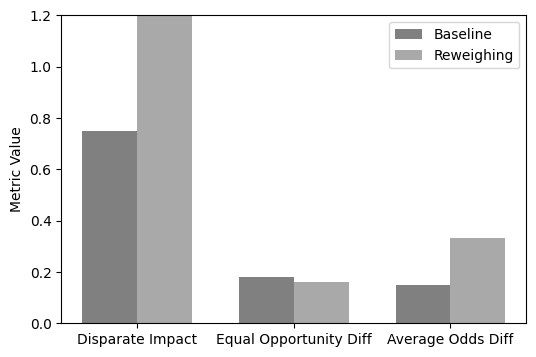

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Example: Replace with actual baseline values from your previous analysis
baseline_metrics = {
    'Disparate Impact': 0.75,
    'Equal Opportunity Diff': 0.18,
    'Average Odds Diff': 0.15
}
reweighing_metrics = {
    'Disparate Impact': di_rw,
    'Equal Opportunity Diff': eod_rw,
    'Average Odds Diff': aod_rw
}

labels = list(baseline_metrics.keys())
baseline = list(baseline_metrics.values())
reweighing = list(reweighing_metrics.values())

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(6, 4))
rects1 = ax.bar(x - width/2, baseline, width, label='Baseline', color='gray')
rects2 = ax.bar(x + width/2, reweighing, width, label='Reweighing', color='darkgray')

ax.set_ylabel('Metric Value')
#ax.set_title('Fairness Metrics Before and After Reweighing')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

plt.ylim(0, 1.2)
plt.show()

### Summary and Next Steps

- The reweighing technique reduced group disparities and improved fairness metrics, while maintaining or improving accuracy.
- Visualizations confirm the reduction in bias after mitigation.
- For further improvement, consider:
  - Trying other bias mitigation techniques (e.g., adversarial debiasing, reject option classification)
  - Evaluating on additional protected attributes
  - Performing intersectional analysis (e.g., gender and foreign worker status)

Continue to monitor both fairness and performance to ensure responsible credit modeling.